# **Data Preprocessing**

In [10]:
# Cargar datos de excel
import pandas as pd
data_22june2020_1 = pd.read_excel('SWaT.A7_June 2020/22June2020 (1).xlsx')
data_22june2020_2 = pd.read_excel('SWaT.A7_June 2020/22June2020 (2).xlsx')
#data_29june2020_1 = pd.read_excel('SWaT.A7_June 2020/29June2020 (1).xlsx')
data_29june2020_2 = pd.read_excel('SWaT.A7_June 2020/29June2020 (2).xlsx')

# Combinar los datos en un solo DataFrame
data = pd.concat([data_22june2020_1, data_22june2020_2, data_29june2020_2], ignore_index=True)
# Mostrar las primeras filas del DataFrame combinado
print(data.head())

                  t_stamp P1_STATE   LIT101.Pv FIT101.Pv MV101.Status  \
0 2020-06-22 10:00:00.000        3    695.2841       0.0            1   
1 2020-06-22 10:00:01.000        3    695.1271       0.0            1   
2 2020-06-22 10:00:02.005        3  694.930847       0.0            1   
3 2020-06-22 10:00:03.010        3  694.930847       0.0            1   
4 2020-06-22 10:00:04.015        3    694.8523       0.0            1   

  P101.Status P102.Status P2_STATE FIT201.Pv  AIT201.Pv  ... FIT601.Pv  \
0           1           1        2  0.000256  18.072288  ...  0.000256   
1           1           1        2  0.000256  18.104332  ...  0.000256   
2           1           1        2  0.000256  18.104332  ...  0.000256   
3           1           1        2  0.000256  18.104332  ...  0.000256   
4           1           1        2  0.000256  18.104332  ...  0.000256   

  P601.Status P602.Status P603.Status LSH601.Alarm LSL601.Alarm LSH602.Alarm  \
0           1           1         1.

In [11]:
# Mostrar columnas del DataFrame
print(data.columns)

# Dimensiones del DataFrame
print(data.shape)  # (número de filas, número de columnas)

# cantidad de columnas numéricas y categóricas
num_cols = data.select_dtypes(include=['number']).columns
cat_cols = data.select_dtypes(include=['object']).columns
print(f'Número de columnas numéricas: {len(num_cols)}')
print(f'Número de columnas categóricas: {len(cat_cols)}')

Index(['t_stamp', 'P1_STATE', 'LIT101.Pv', 'FIT101.Pv', 'MV101.Status',
       'P101.Status', 'P102.Status', 'P2_STATE', 'FIT201.Pv', 'AIT201.Pv',
       'AIT202.Pv', 'AIT203.Pv', 'MV201.Status', 'P201.Status', 'P202.Status',
       'P203.Status', 'P204.Status', 'P205.Status', 'P206.Status',
       'P207.Status', 'P208.Status', 'LS201.Alarm', 'LS202.Alarm',
       'LSL203.Alarm', 'LSLL203.Alarm', 'P3_STATE', 'AIT301.Pv', 'AIT302.Pv',
       'AIT303.Pv', 'LIT301.Pv', 'FIT301.Pv', 'DPIT301.Pv', 'MV301.Status',
       'MV302.Status', 'MV303.Status', 'MV304.Status', 'P301.Status',
       'P302.Status', 'PSH301.Alarm', 'DPSH301.Alarm', 'P4_STATE', 'LIT401.Pv',
       'FIT401.Pv', 'AIT401.Pv', 'AIT402.Pv', 'P401.Status', 'P402.Status',
       'P403.Status', 'P404.Status', 'UV401.Status', 'LS401.Alarm', 'P5_STATE',
       'FIT501.Pv', 'FIT502.Pv', 'FIT503.Pv', 'FIT504.Pv', 'AIT501.Pv',
       'AIT502.Pv', 'AIT503.Pv', 'AIT504.Pv', 'PIT501.Pv', 'PIT502.Pv',
       'PIT503.Pv', 'P501.Status', '

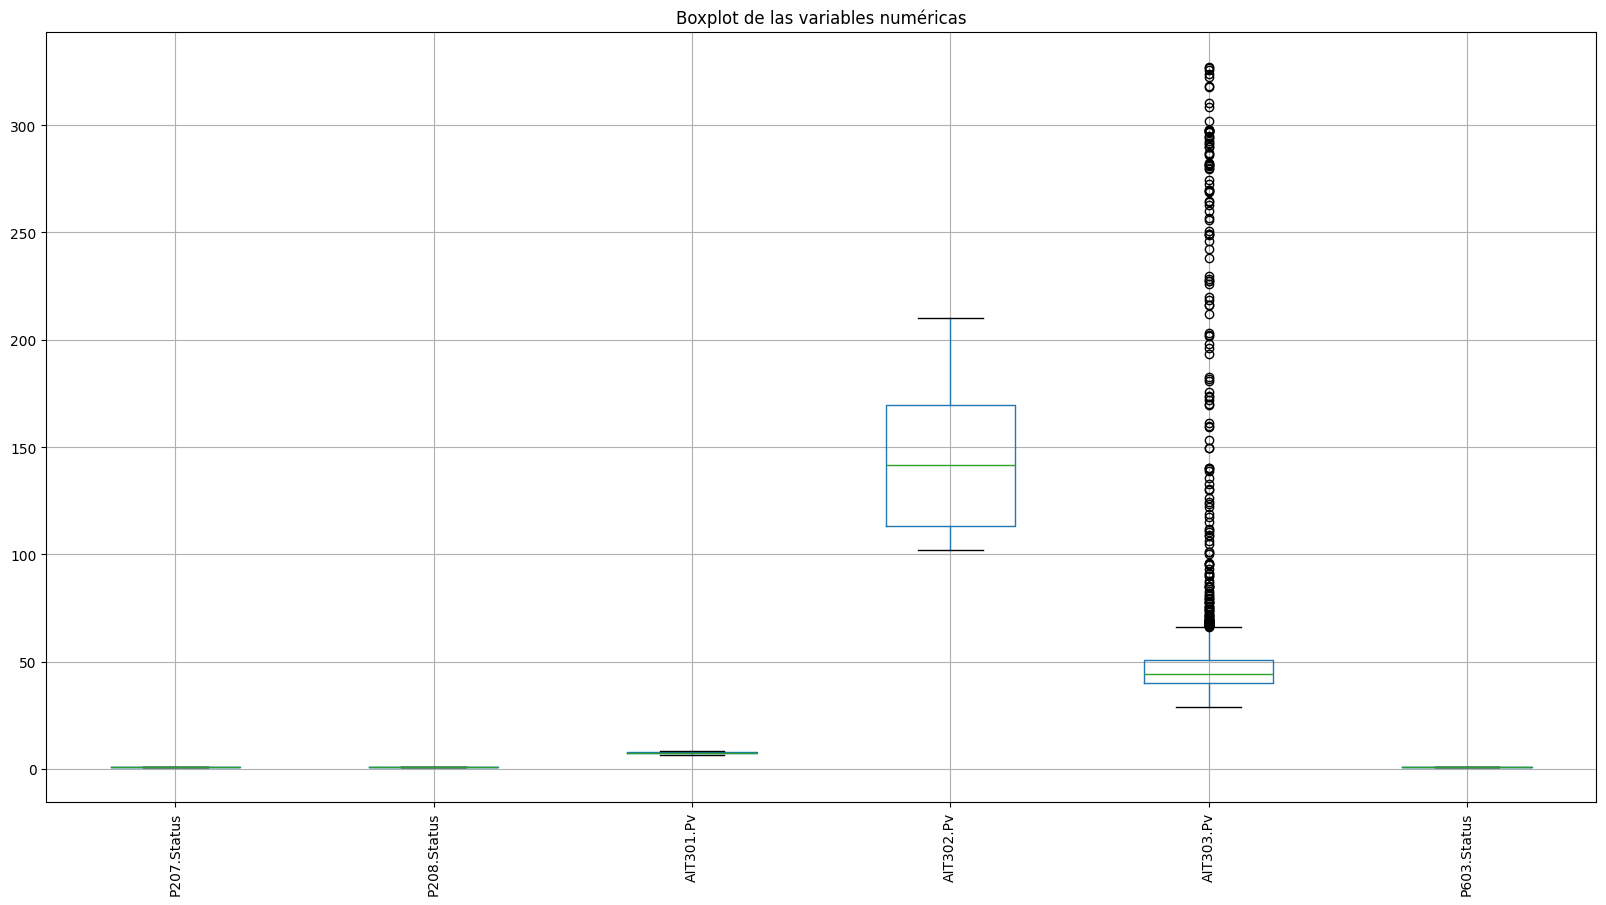

In [12]:
# Boxplot de las variables numéricas
import matplotlib.pyplot as plt
data.boxplot(figsize=(20, 10))
plt.xticks(rotation=90)
plt.title('Boxplot de las variables numéricas')
plt.show()


In [ ]:
# Convertir columna t_stamp a formato datetime
data['t_stamp'] = pd.to_datetime(data['t_stamp'], errors='coerce')
data['t_stamp'].head()

# Ordenar el DataFrame por la columna t_stamp
data = data.sort_values(by='t_stamp').reset_index(drop=True)

# Convertir columnas numéricas a tipo float
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    
# Convertir columnas categoricas a estados binarios, inactive = 0, active = 1
for col in cat_cols:
    data[col] = data[col].map({'inactive': 0, 'active': 1})
    
# Revisar frecuencia de muestreo real
data['t_stamp'].diff().value_counts()

t_stamp
0 days 00:00:01.005000    14398
0 days 00:00:01           10801
6 days 23:28:49.010000        1
Name: count, dtype: int64